<a href="https://colab.research.google.com/github/JantikarShobith/BIS_LAB/blob/main/BIS_Week2_PSO.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Iteration   1 | Best System Cost: 63949.63
Iteration  20 | Best System Cost: 56182.24
Iteration  40 | Best System Cost: 55676.43
Iteration  60 | Best System Cost: 55608.27
Iteration  80 | Best System Cost: 55601.34
Iteration 100 | Best System Cost: 55600.33

   OPTIMAL BUS STOP PLACEMENT RESULTS   
 Bus Stop 1 Location :  50.00 meters
 Bus Stop 2 Location : 420.00 meters
 Bus Stop 3 Location : 850.00 meters
 Total System Cost   : 55600.33 passenger-meters


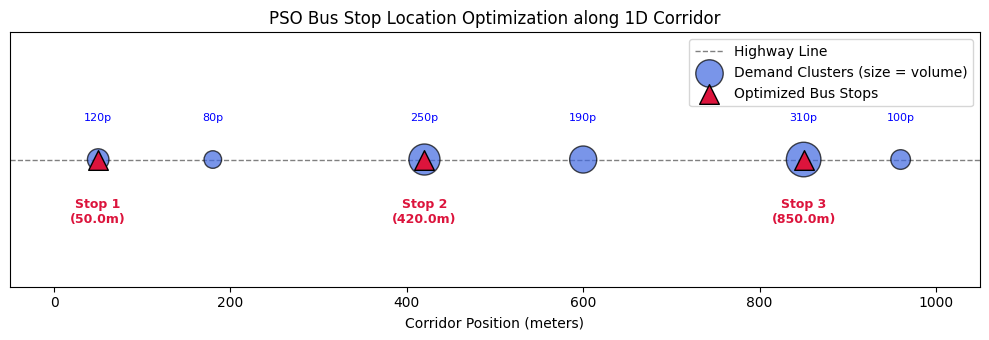

In [5]:
import numpy as np
import matplotlib.pyplot as plt


ROAD_LENGTH = 1000.0
NUM_STOPS = 3
MIN_STOP_DISTANCE = 150.0
PENALTY_WEIGHT = 500.0


DEMAND_POINTS = np.array([
    [ 50.0, 120.0],
  [180.0,  80.0],
    [420.0, 250.0],
    [600.0, 190.0],
    [850.0, 310.0],
    [960.0, 100.0]
])


SWARM_SIZE = 30
MAX_ITER = 100
W = 0.729    # Inertia weight
C1 = 1.494   # Cognitive coefficient
C2 = 1.494   # Social coefficient
V_MAX = ROAD_LENGTH * 0.1


# ---------------------------------------------------------
# 3. Fitness Function
# ---------------------------------------------------------
def evaluate_fitness(stops):
    """
    Calculates total weighted walking distance + proximity penalties.
    stops: 1D array of shape (NUM_STOPS,)
    """
    positions = DEMAND_POINTS[:, 0]  # Demand point locations
    weights = DEMAND_POINTS[:, 1]    # Passenger volumes

    # 1. Passenger Walking Cost
    # Compute absolute differences between every demand point and every stop
    # Shape: (num_demand_points, num_stops)
    distances = np.abs(positions[:, np.newaxis] - stops)

    # Nearest stop distance for each demand point
    min_distances = np.min(distances, axis=1)

    # Total weighted walking cost
    total_walk_cost = np.sum(weights * min_distances)

    # 2. Proximity Penalty for stops placed too close together
    sorted_stops = np.sort(stops)
    gaps = np.diff(sorted_stops)

    penalty = 0.0
    violations = MIN_STOP_DISTANCE - gaps[gaps < MIN_STOP_DISTANCE]
    if len(violations) > 0:
        penalty = np.sum(violations) * PENALTY_WEIGHT

    return total_walk_cost + penalty


# ---------------------------------------------------------
# 4. Main Particle Swarm Optimization Loop
# ---------------------------------------------------------
def run_pso():
    np.random.seed(42)  # For reproducible results

    # Initialize Particle Swarm
    # Positions shape: (SWARM_SIZE, NUM_STOPS)
    positions = np.random.uniform(0.0, ROAD_LENGTH, size=(SWARM_SIZE, NUM_STOPS))
    velocities = np.random.uniform(-V_MAX, V_MAX, size=(SWARM_SIZE, NUM_STOPS))

    pbest_positions = positions.copy()
    pbest_fitness = np.array([evaluate_fitness(p) for p in positions])

    # Global best initialization
    gbest_index = np.argmin(pbest_fitness)
    gbest_position = pbest_positions[gbest_index].copy()
    gbest_fitness = pbest_fitness[gbest_index]

    # Optimization Loop
    for iteration in range(MAX_ITER):
        for i in range(SWARM_SIZE):
            r1 = np.random.uniform(0.0, 1.0, size=NUM_STOPS)
            r2 = np.random.uniform(0.0, 1.0, size=NUM_STOPS)

            # Velocity Update Equation
            velocities[i] = (W * velocities[i] +
                             C1 * r1 * (pbest_positions[i] - positions[i]) +
                             C2 * r2 * (gbest_position - positions[i]))

            # Clamp Velocities
            velocities[i] = np.clip(velocities[i], -V_MAX, V_MAX)

            # Position Update Equation
            positions[i] += velocities[i]

            # Clamp Positions within road boundaries [0, ROAD_LENGTH]
            positions[i] = np.clip(positions[i], 0.0, ROAD_LENGTH)

            # Evaluate Fitness
            current_fitness = evaluate_fitness(positions[i])

            # Update Personal Best
            if current_fitness < pbest_fitness[i]:
                pbest_fitness[i] = current_fitness
                pbest_positions[i] = positions[i].copy()

                # Update Global Best
                if current_fitness < gbest_fitness:
                    gbest_fitness = current_fitness
                    gbest_position = positions[i].copy()

        # Print progress periodically
        if (iteration + 1) % 20 == 0 or iteration == 0:
            print(f"Iteration {iteration + 1:3d} | Best System Cost: {gbest_fitness:.2f}")

    return np.sort(gbest_position), gbest_fitness


# ---------------------------------------------------------
# 5. Execute and Visualize
# ---------------------------------------------------------
optimal_stops, best_cost = run_pso()

print("\n========================================")
print("   OPTIMAL BUS STOP PLACEMENT RESULTS   ")
print("========================================")
for idx, stop in enumerate(optimal_stops, 1):
    print(f" Bus Stop {idx} Location : {stop:6.2f} meters")
print(f" Total System Cost   : {best_cost:.2f} passenger-meters")
print("========================================")

# Plotting the Network Setup
plt.figure(figsize=(10, 3.5))
plt.axhline(0, color='gray', linestyle='--', linewidth=1, label="Highway Line")

# Plot Demand Points
demand_x = DEMAND_POINTS[:, 0]
demand_w = DEMAND_POINTS[:, 1]
plt.scatter(demand_x, np.zeros_like(demand_x), s=demand_w*2, color='royalblue',
            alpha=0.7, edgecolors='black', label='Demand Clusters (size = volume)', zorder=3)

# Plot Optimal Bus Stops
plt.scatter(optimal_stops, np.zeros_like(optimal_stops), color='crimson',
            s=200, marker='^', edgecolors='black', label='Optimized Bus Stops', zorder=4)

# Annotations
for x, w in DEMAND_POINTS:
    plt.text(x, 0.03, f"{int(w)}p", ha='center', fontsize=8, color='blue')

for idx, stop in enumerate(optimal_stops, 1):
    plt.text(stop, -0.05, f"Stop {idx}\n({stop:.1f}m)", ha='center', fontsize=9, color='crimson', weight='bold')

plt.title("PSO Bus Stop Location Optimization along 1D Corridor")
plt.xlabel("Corridor Position (meters)")
plt.yticks([])
plt.xlim(-50, ROAD_LENGTH + 50)
plt.ylim(-0.1, 0.1)
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()